In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
example_data = pd.read_csv('../data/5/exp05H20140926_10h50.csv')

In [17]:
n = 5
alignment = pd.DataFrame(index=example_data.index)

for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        alignment[f"{i}_{j}"] = np.cos(example_data[f"H{i}"] - example_data[f"H{j}"])

- Close to 1 ~ similar direction/aligment
- Close to 0 ~ uncoordinated
- Close to -1 ~ opposite direction/aligment

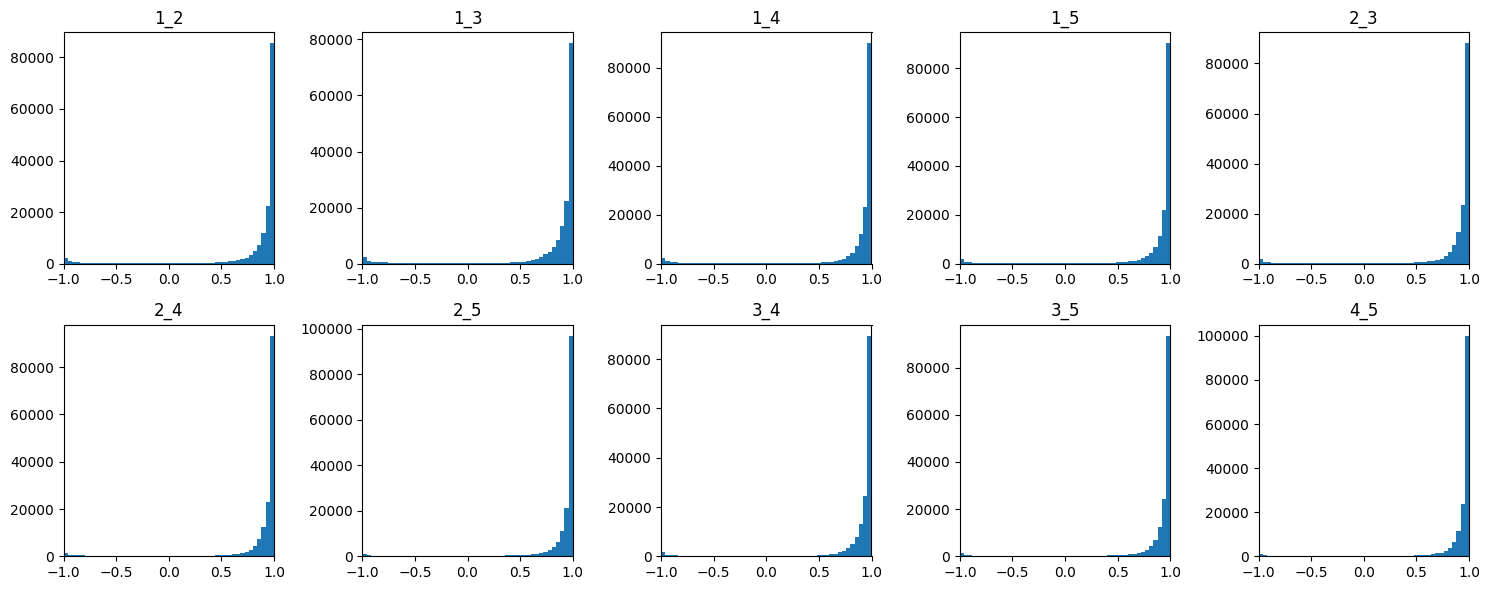

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(alignment.columns):
    axes[i].hist(alignment[col], bins=50)
    axes[i].set_title(col)
    axes[i].set_xlim(-1, 1) 


plt.tight_layout()
plt.show()

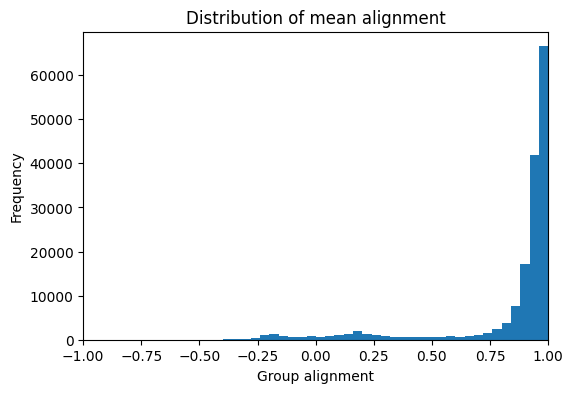

In [21]:
mean_alignment = alignment.mean(axis=1)

plt.figure(figsize=(6,4))
plt.hist(mean_alignment, bins=50)

plt.xlabel("Group alignment")
plt.ylabel("Frequency")
plt.title("Distribution of mean alignment")
plt.xlim(-1, 1)
plt.show()

In [22]:
print(mean_alignment.describe())

count    162774.000000
mean          0.842580
std           0.277835
min          -0.998704
25%           0.891651
50%           0.949253
75%           0.974846
max           0.999996
dtype: float64


In [41]:
n = 5
speed = pd.DataFrame(index=example_data.index)

for i in range(1, n + 1):
    dx = np.gradient(example_data[f"X{i}"])
    dy = np.gradient(example_data[f"Y{i}"])
    
    speed[f"{i}"] = np.hypot(dx, dy) * 50 # fps

speed_diff = pd.DataFrame(index=example_data.index)

for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        speed_diff[f"{i}_{j}"] = speed[f"{i}"] - speed[f"{j}"]

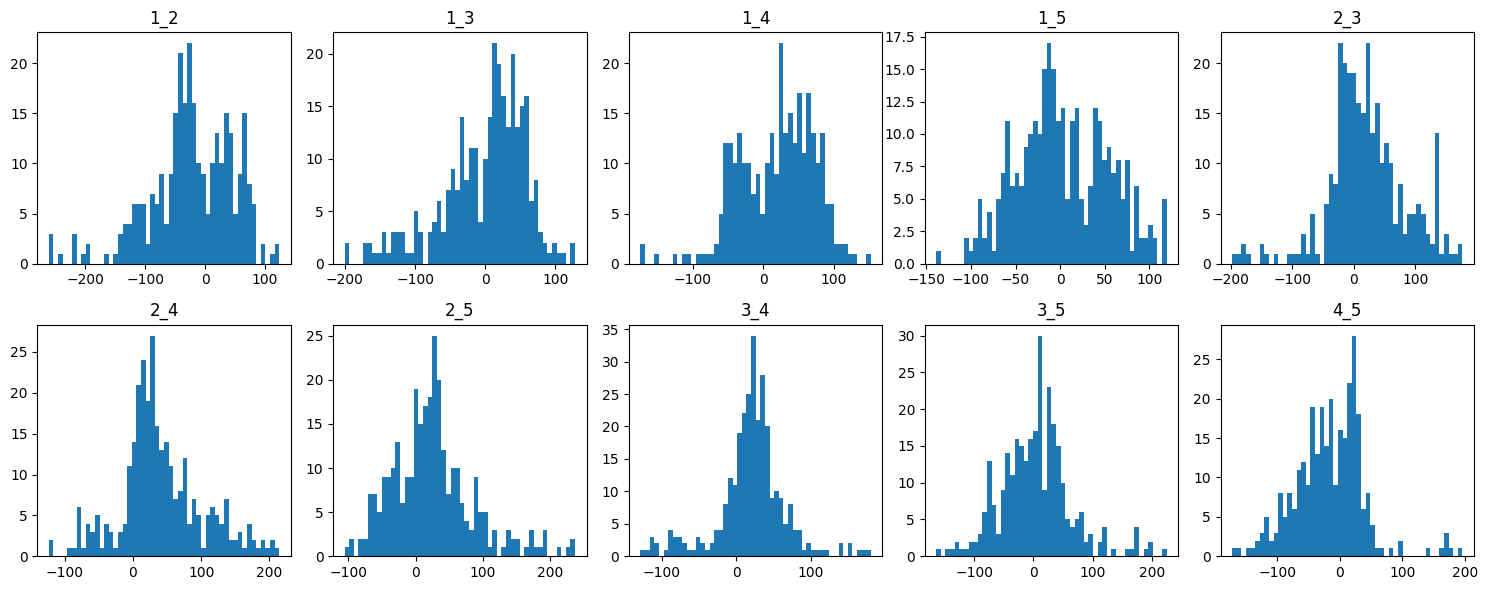

In [42]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(speed_diff.columns):
    axes[i].hist(speed_diff[col], bins=50)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

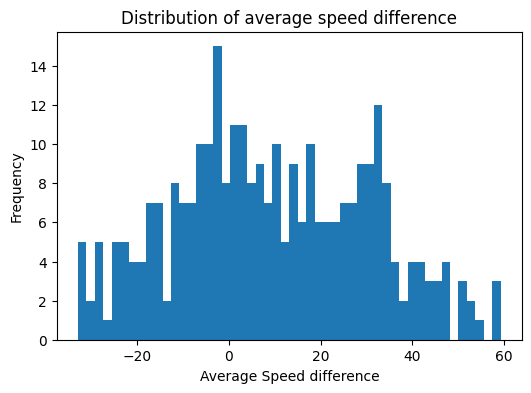

In [43]:
mean_speed_diff = speed_diff.mean(axis=1)

plt.figure(figsize=(6,4))
plt.hist(mean_speed_diff, bins=50)

plt.title("Distribution of average speed difference")
plt.xlabel("Average Speed difference")
plt.ylabel("Frequency")
plt.show()

In [44]:
print(mean_speed_diff.describe())

count    301.000000
mean       9.403312
std       21.288257
min      -32.966518
25%       -5.432083
50%        7.513235
75%       26.730742
max       59.368628
dtype: float64


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Assuming 'example_data' (positions) and 'separations' (distances) 
# are already in your notebook's memory from your previous cells.

example_data = example_data.loc[10200:10500]
alignments = alignment.loc[10200:10500]

# 1. Setup the Figure and Axes (1 row, 2 columns)
fig, (ax_traj, ax_bar) = plt.subplots(1, 2, figsize=(16, 6))

# --- Setup Scatter Plot (Fish Movement) ---
# Extract coordinate column names dynamically for n=5
x_cols = [f"X{i}" for i in range(1, 6)]
y_cols = [f"Y{i}" for i in range(1, 6)]

# Find the global min and max for consistent axis limits
x_min, x_max = example_data[x_cols].min().min(), example_data[x_cols].max().max()
y_min, y_max = example_data[y_cols].min().min(), example_data[y_cols].max().max()

ax_traj.set_xlim(x_min - 10, x_max + 10) # Padding so fish don't hit the edges
ax_traj.set_ylim(y_min - 10, y_max + 10)
ax_traj.set_title("Fish Trajectories (Overhead View)", fontsize=14)
ax_traj.set_xlabel("X Coordinate")
ax_traj.set_ylabel("Y Coordinate")

# Initialize the scatter plot points
# Initialize with the first frame's data to avoid the size mismatch error
colors = ['red', 'blue', 'green', 'orange', 'purple']
initial_x = example_data[x_cols].iloc[0].values
initial_y = example_data[y_cols].iloc[0].values
scat = ax_traj.scatter(initial_x, initial_y, c=colors, s=150, edgecolors='black', zorder=5)


# --- Setup Bar Chart ---
sep_cols = alignments.columns
x_pos = np.arange(len(sep_cols))

# Initialize empty bars
bars = ax_bar.bar(x_pos, np.zeros(len(sep_cols)), color='skyblue', edgecolor='black')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(sep_cols, rotation=45)

# Set static Y-axis limit based on the maximum separation ever achieved
max_alig = alignments.max().max()
ax_bar.set_ylim(0, max_alig * 1.1) 
ax_bar.set_title("Pairwise Alignment", fontsize=14)

# 2. The Update Function (Called once per frame)
def update(frame):
    # Update scatter plot positions
    current_x = example_data[x_cols].iloc[frame].values
    current_y = example_data[y_cols].iloc[frame].values
    scat.set_offsets(np.c_[current_x, current_y])
            
    # Update bar chart heights
    current_seps = alignments.iloc[frame].values
    for bar, h in zip(bars, current_seps):
        bar.set_height(h)
        
    # Update title to show time or frame
    fig.suptitle(f"Frame: {frame}", fontsize=16, fontweight='bold')
    
    return scat, *bars

# 3. Compile the Animation
# Note: For testing, you might want to limit frames (e.g., frames=500) rather than len(example_data)
total_frames = len(example_data)
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50, blit=False)

plt.close(fig) # Prevents the static empty plot from showing up in Jupyter

# 4. Display or Export
# To view directly inside the Jupyter Notebook:
# display(HTML(ani.to_jshtml()))

# To save as an MP4 for your video presentation (Requires FFmpeg installed):
ani.save("fish_turn_event_alignment.mp4", writer='ffmpeg', fps=20, dpi=150)

/var/folders/kj/n5mh3n_95kd1y2mn73_0p7vc0000gn/T/ipykernel_26198/1538823656.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_traj.legend()
